# Day 45: T-Test vs Z-Test (Variance Uncertainty & Convergence)

Today I explored the difference between the Z-test and T-test.

## Learning Objectives:
- Understand when to use Z-test (known population standard deviation).
- Understand when to use T-test (unknown population standard deviation).
- Learn why T-distribution has heavier tails.
- Observe how T-test converges to Z-test as sample size increases.
- Visualize p-value convergence numerically and graphically.

## Key Insights:
- T-test uses sample standard deviation, which introduces extra uncertainty.
- For small sample sizes, T-test produces slightly larger p-values.
- As sample size increases, sample variance stabilizes.
- T-distribution converges to Normal distribution as n → large.
- Z-test and T-test become nearly identical for large samples.

## Mini Project:
Built a simulation comparing Z-test and T-test across multiple sample sizes and visualized convergence of p-values.

This reinforces understanding of statistical inference and variance estimation in real-world scenarios.

In [6]:
# Import necessary libraries
import numpy as np
import scipy.stats as stats

# Set a random seed for reproducibility
np.random.seed(42)

# Define the null hypothesis population mean (mu)
mu = 70

# Generate a sample from a normal distribution with a true mean of 73 and std dev of 10
# This sample will be used to test against the null hypothesis mean of 70
Sample = np.random.normal(loc=73, scale=10, size=20)

# Perform a one-sample t-test to compare the sample mean to the hypothesized population mean (mu)
T_stat, P_value = stats.ttest_1samp(Sample, mu)

# Print the sample mean, t-statistic, and p-value
print("Sample mean:", np.mean(Sample))
print("t-statistic:", T_stat)
print("p-value:", P_value)

# Interpret the results based on the p-value and a significance level of 0.05
if P_value < 0.05:
    print("Reject the null hypothesis. The mean weight is significantly different from 70.")
else:
    print("Fail to reject the null hypothesis. The mean weight is not significantly different from 70.")

Sample mean: 71.28701438558171
t-statistic: 0.5995346783311071
p-value: 0.5558991132093789
Fail to reject the null hypothesis. The mean weight is not significantly different from 70.


Small Sample (n=20)
Z-test p-value: 0.21546233986221308
T-test p-value: 0.22364451517657094

Large Sample (n=200)
Z-test p-value: 5.102618918506607e-07
T-test p-value: 1.6701443214793726e-06


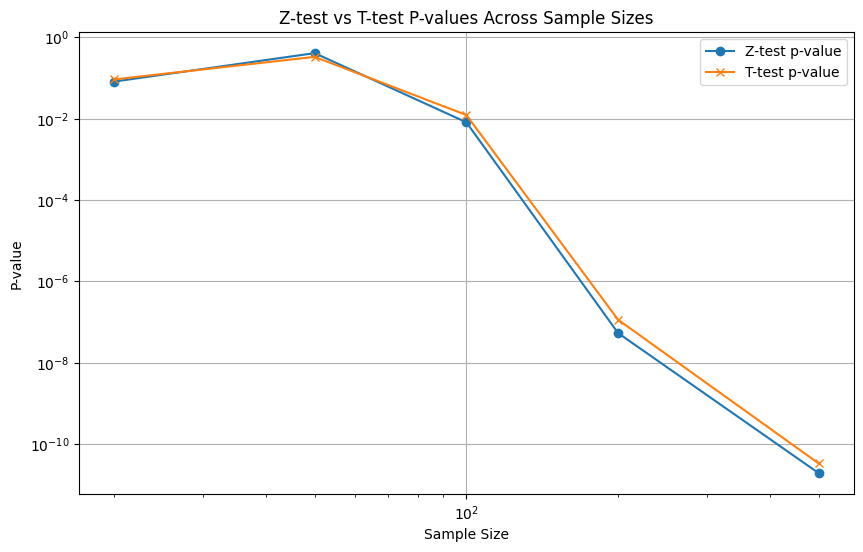

In [7]:
# Import necessary libraries for numerical operations, plotting, and statistical tests
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# -----------------------------------------------------------------------------
# Set Reproducibility: Ensures that random number generation is consistent
# -----------------------------------------------------------------------------
np.random.seed(43)

# -----------------------------------------------------------------------------
# Define Population Parameters for the simulation
# -----------------------------------------------------------------------------
population_mean = 70      # The hypothesized mean under the null hypothesis
population_std = 10       # The true standard deviation of the population (assumed known for Z-test)
true_improved_mean = 73   # The actual mean of the population we are sampling from (e.g., after an intervention)


# -----------------------------------------------------------------------------
# Function to Compare Z-test and T-test for a given sample size
# -----------------------------------------------------------------------------
def compare_tests(sample_size):

    # Generate a sample from the 'improved' population distribution
    sample = np.random.normal(
        loc=true_improved_mean,   # The true mean from which the sample is drawn
        scale=population_std,     # The true standard deviation of the population
        size=sample_size          # The desired size of the sample
    )

    # Compute sample statistics: mean and standard deviation
    sample_mean = np.mean(sample)
    # Calculate sample standard deviation with Bessel's correction (ddof=1)
    sample_std = np.std(sample, ddof=1)

    # -------------------------------------------------------------------------
    # Z-Test: Assumes the population standard deviation is known
    # -------------------------------------------------------------------------
    # Z-statistic calculation
    z_stat = (sample_mean - population_mean) / (population_std / np.sqrt(sample_size))
    # Two-tailed p-value calculation for Z-test
    z_p = 2 * (1 - stats.norm.cdf(abs(z_stat)))

    # -------------------------------------------------------------------------
    # T-Test: Uses the sample standard deviation when population std is unknown
    # -------------------------------------------------------------------------
    # Perform a one-sample t-test
    t_stat, t_p = stats.ttest_1samp(sample, population_mean)

    return z_p, t_p


# -----------------------------------------------------------------------------
# Compare Z-test and T-test with a Small Sample Size
# -----------------------------------------------------------------------------
n_small = 20
z_small, t_small = compare_tests(n_small)

print("Small Sample (n=20)")
print("Z-test p-value:", z_small)
print("T-test p-value:", t_small)


# -----------------------------------------------------------------------------
# Compare Z-test and T-test with a Large Sample Size
# -----------------------------------------------------------------------------
n_large = 200
z_large, t_large = compare_tests(n_large)

print("\nLarge Sample (n=200)")
print("Z-test p-value:", z_large)
print("T-test p-value:", t_large)


# -----------------------------------------------------------------------------
# Compare Z-test and T-test across Multiple Sample Sizes to observe convergence
# -----------------------------------------------------------------------------
sample_sizes = [20, 50, 100, 200, 500] # Define a range of sample sizes to test
z_values = [] # List to store p-values from Z-tests
t_values = [] # List to store p-values from T-tests

# Iterate through each sample size and perform the comparison
for size in sample_sizes:
    z_p, t_p = compare_tests(size)
    z_values.append(z_p)
    t_values.append(t_p)

# -----------------------------------------------------------------------------
# Plot the Comparison of P-values: Z-test vs. T-test across Sample Sizes
# -----------------------------------------------------------------------------
plt.figure(figsize=(10, 6)) # Create a figure with a specified size
plt.plot(sample_sizes, z_values, label='Z-test p-value', marker='o') # Plot Z-test p-values
plt.plot(sample_sizes, t_values, label='T-test p-value', marker='x') # Plot T-test p-values
plt.xlabel("Sample Size")
plt.ylabel("P-value")
plt.title("Z-test vs T-test P-values Across Sample Sizes")
plt.legend() # Display the legend to distinguish lines
plt.grid(True) # Add a grid for better readability
plt.xscale('log') # Use a logarithmic scale for the x-axis to better show progression
plt.yscale('log') # Use a logarithmic scale for the y-axis to better show small p-values
plt.show() # Display the plot